# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Makeup Sales in 2025 Dataset](https://www.kaggle.com/datasets/syedaeman2212/makeup-sales-in-2025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/syedaeman2212/makeup-sales-in-2025/makeup_sales_dataset_2025.csv


## Import CSV And convert to DataFrame

In [52]:
df = pd.read_csv('makeup_sales_dataset_2025.csv')

# Preprocessing

## Frist five row

In [53]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


## last Five row

In [54]:
df.tail()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
495,496,2025-09-25,L'Oreal,Highlighter,UAE,Beauty Salon,Card,84.15,40,3366.00
496,497,2025-12-06,MAC,Foundation,USA,Retail Store,Digital Wallet,82.77,25,2069.25
497,498,2025-08-29,L'Oreal,Eyeshadow,France,Retail Store,Card,102.97,11,1132.67
498,499,2025-05-23,NARS,Highlighter,UAE,Online,Card,10.79,15,161.85
499,500,2025-08-16,L'Oreal,Eyeshadow,Canada,Mall,Cash,97.15,29,2817.35


## Shape of our dataset

In [55]:
df.shape

(500, 10)

## List out all columns

In [56]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel',
       'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

## Datatype of each columns

In [57]:
df.dtypes

Sale_ID             int64
Date               object
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object

## Information of all Columns

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


## Check Null Value

In [59]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

## Check Dupicate Value

In [60]:
df.duplicated().sum()

np.int64(0)

## Summary

In [61]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.00000
mean,250.500000,62.857760,25.416000,1586.37700
std,144.481833,32.609632,14.217426,1284.13365
min,1.000000,5.250000,1.000000,25.64000
25%,125.750000,35.512500,13.000000,536.67250
50%,250.500000,61.225000,26.000000,1241.12500
75%,375.250000,90.775000,37.000000,2345.87750
max,500.000000,119.930000,50.000000,5987.50000


# EDA

In [62]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

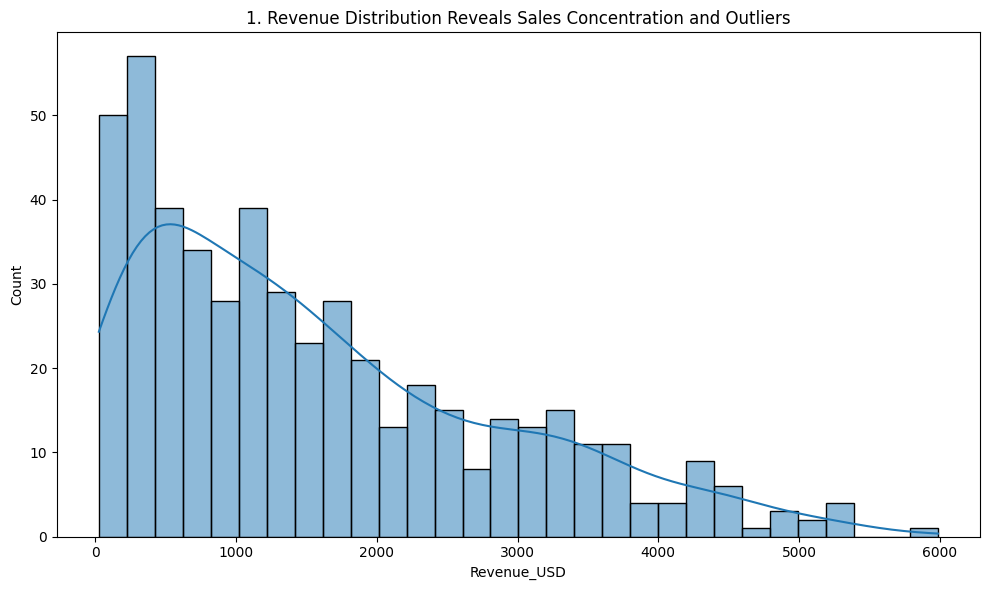

In [63]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Revenue_USD'], bins=30, kde=True)
plt.title(f'{plot_no}. Revenue Distribution Reveals Sales Concentration and Outliers')
show_fig()
plot_no += 1

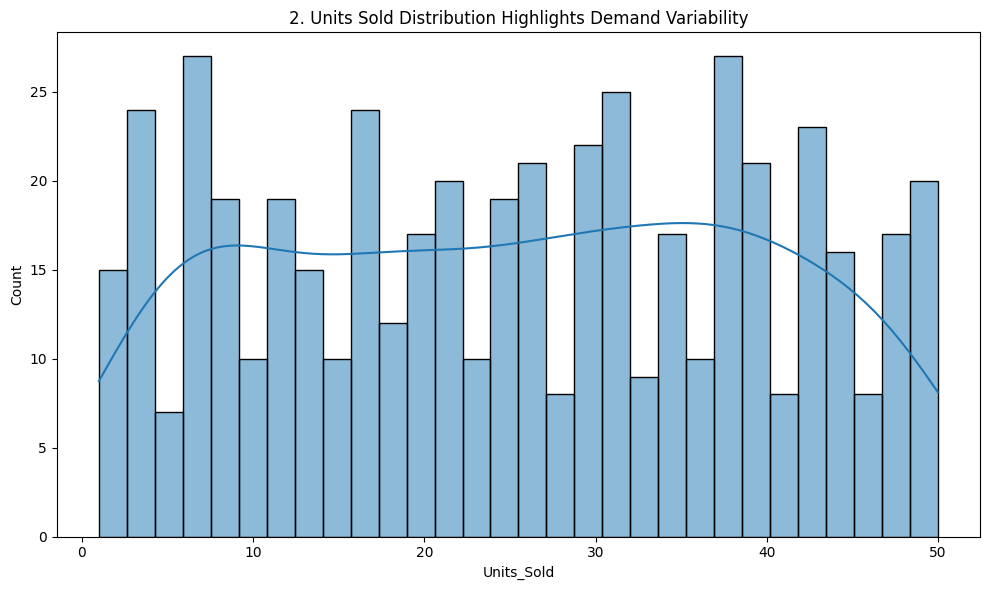

In [64]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title(f'{plot_no}. Units Sold Distribution Highlights Demand Variability')
show_fig()
plot_no += 1

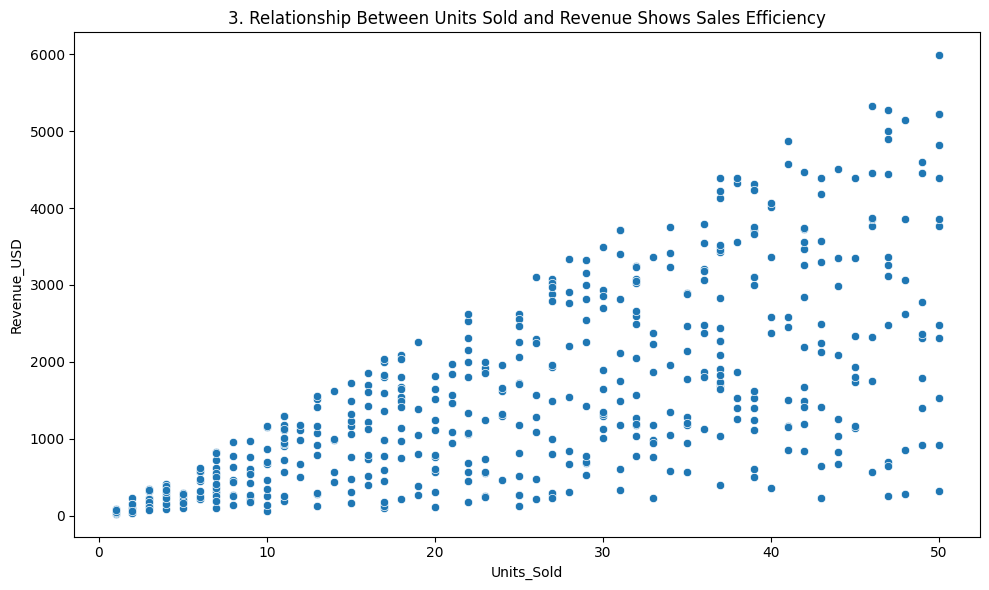

In [65]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Units_Sold', y='Revenue_USD', data=df)
plt.title(f'{plot_no}. Relationship Between Units Sold and Revenue Shows Sales Efficiency')
show_fig()
plot_no += 1

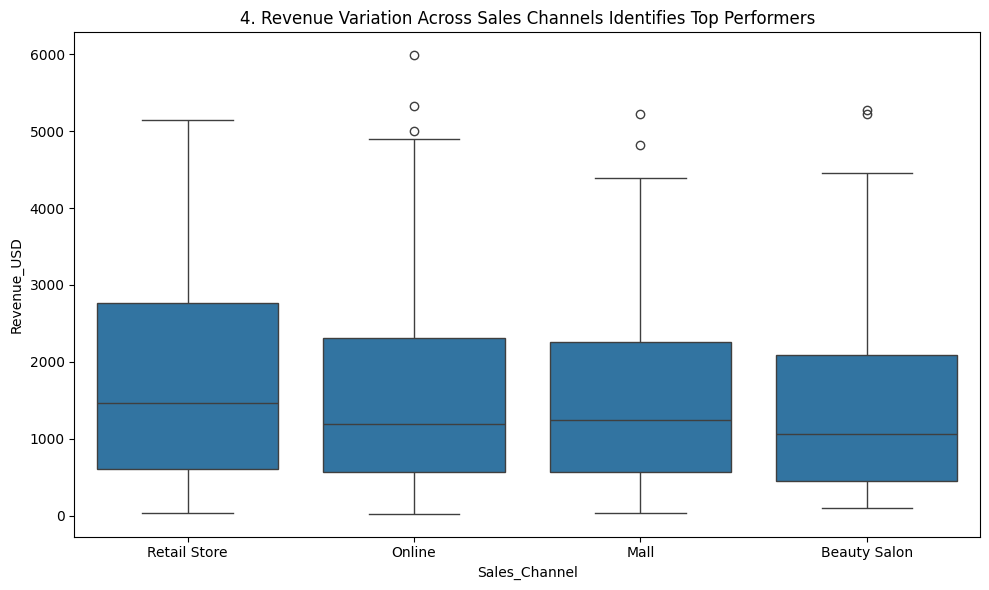

In [66]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Sales_Channel', y='Revenue_USD', data=df)
plt.title(f'{plot_no}. Revenue Variation Across Sales Channels Identifies Top Performers')
show_fig()
plot_no += 1

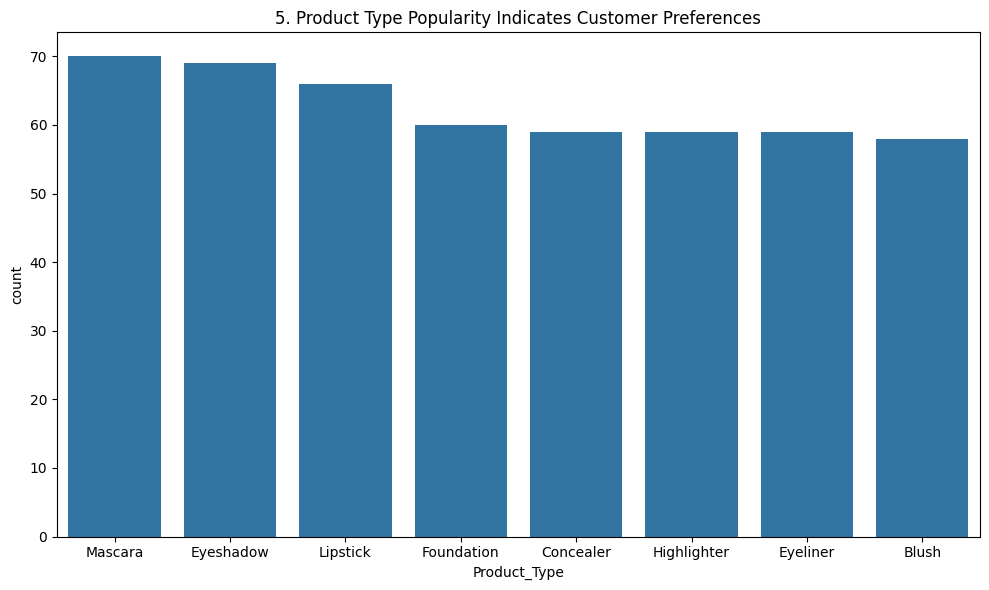

In [67]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Product_Type', data=df, order=df['Product_Type'].value_counts().index)
plt.title(f'{plot_no}. Product Type Popularity Indicates Customer Preferences')
show_fig()
plot_no += 1

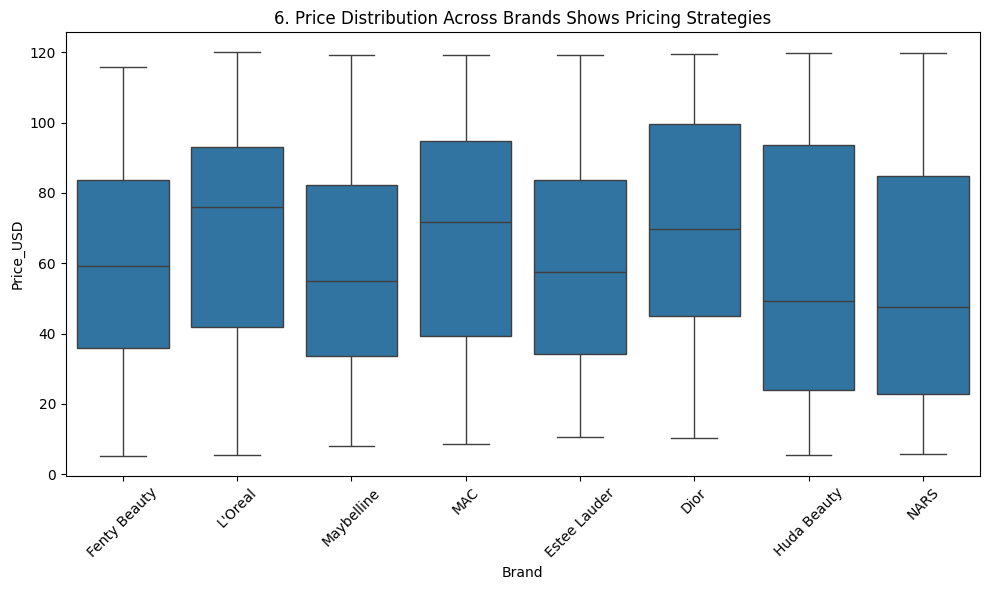

In [68]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Brand', y='Price_USD', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Price Distribution Across Brands Shows Pricing Strategies')
show_fig()
plot_no += 1

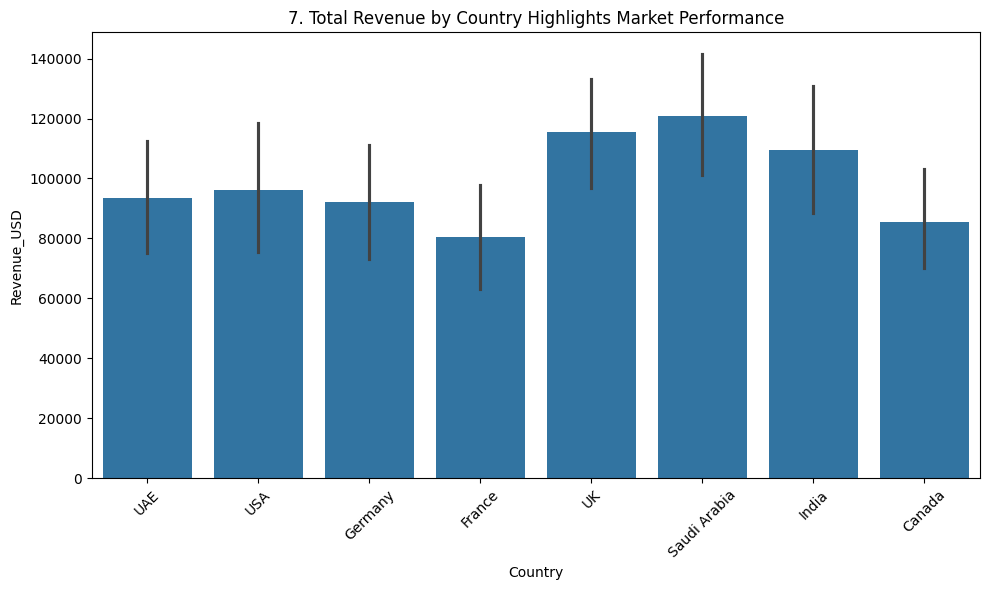

In [69]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Country', y='Revenue_USD', data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Total Revenue by Country Highlights Market Performance')
show_fig()
plot_no += 1

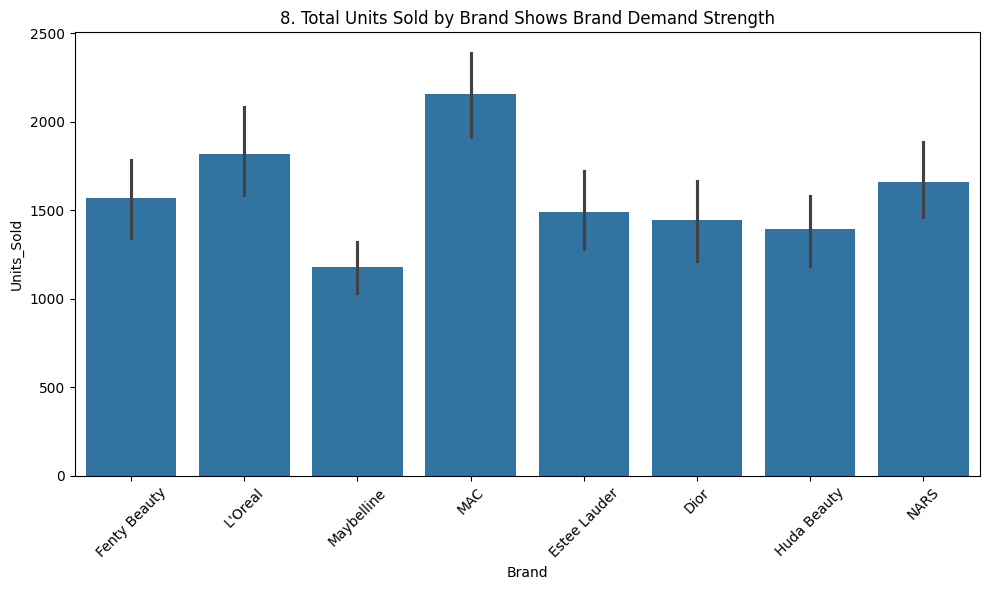

In [70]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Brand', y='Units_Sold', data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Total Units Sold by Brand Shows Brand Demand Strength')
show_fig()
plot_no += 1

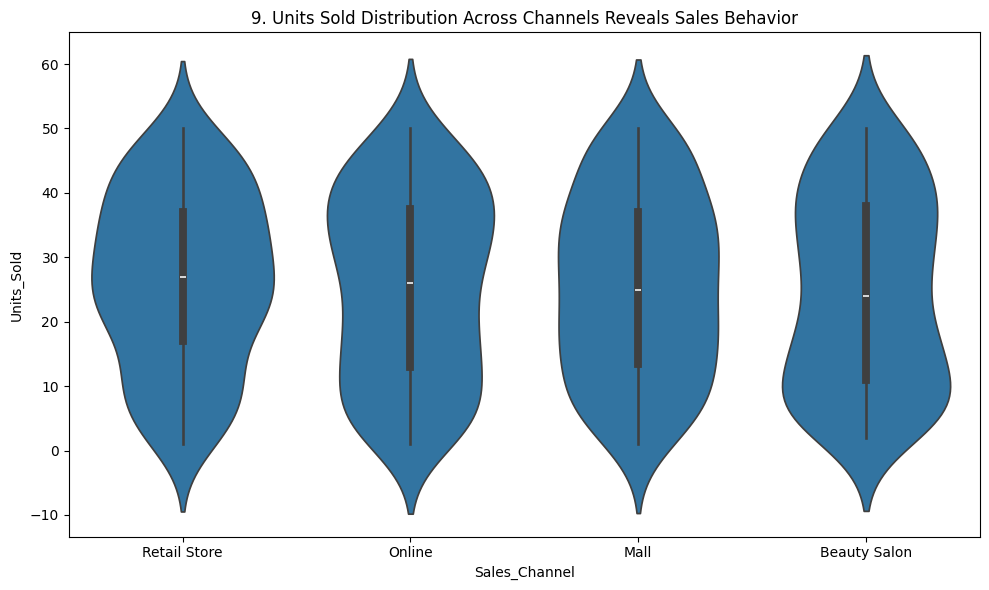

In [71]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Sales_Channel', y='Units_Sold', data=df)
plt.title(f'{plot_no}. Units Sold Distribution Across Channels Reveals Sales Behavior')
show_fig()
plot_no += 1

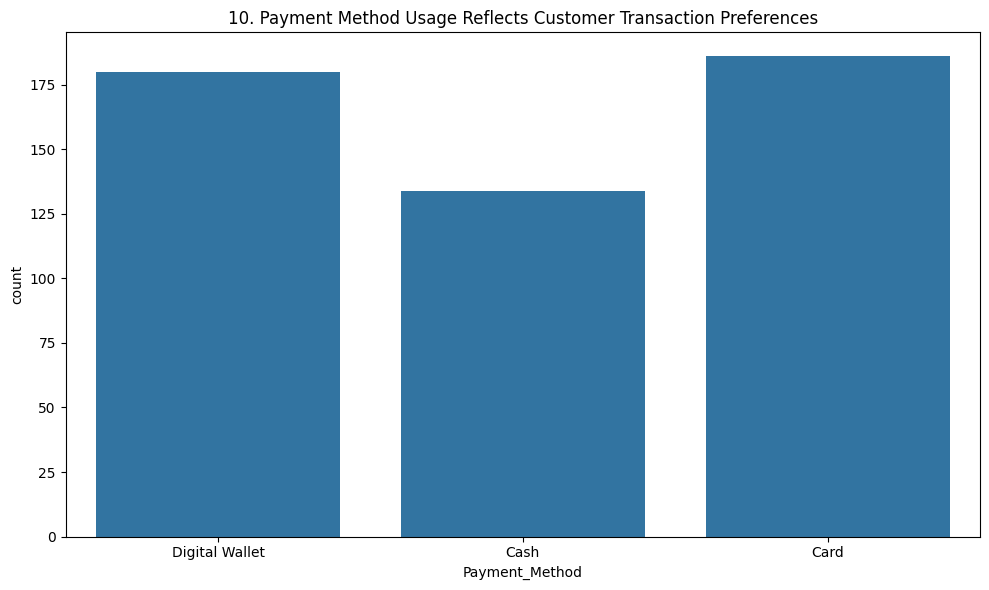

In [72]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Payment_Method', data=df)
plt.title(f'{plot_no}. Payment Method Usage Reflects Customer Transaction Preferences')
show_fig()
plot_no += 1

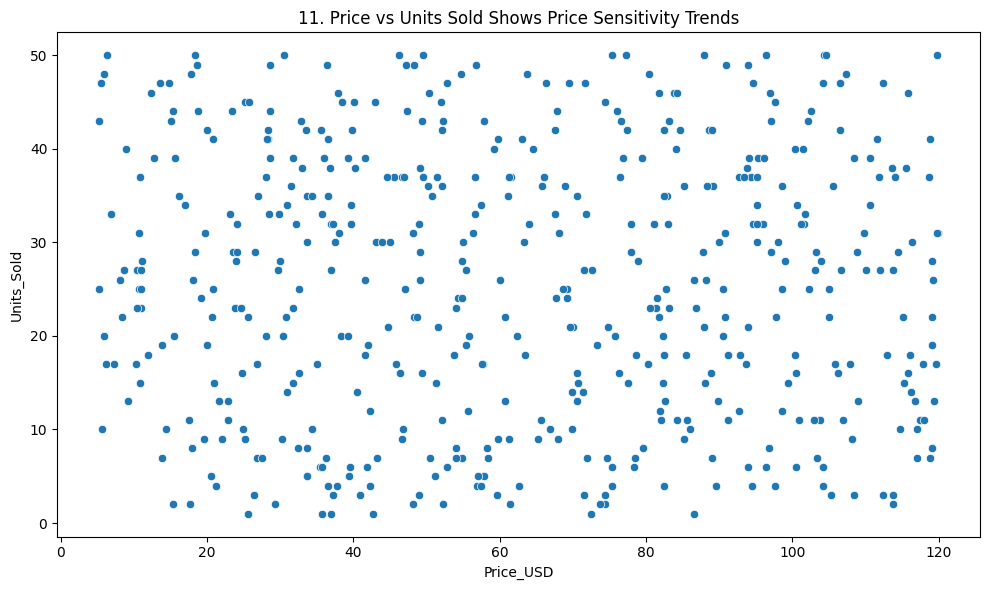

In [73]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Price_USD', y='Units_Sold', data=df)
plt.title(f'{plot_no}. Price vs Units Sold Shows Price Sensitivity Trends')
show_fig()
plot_no += 1

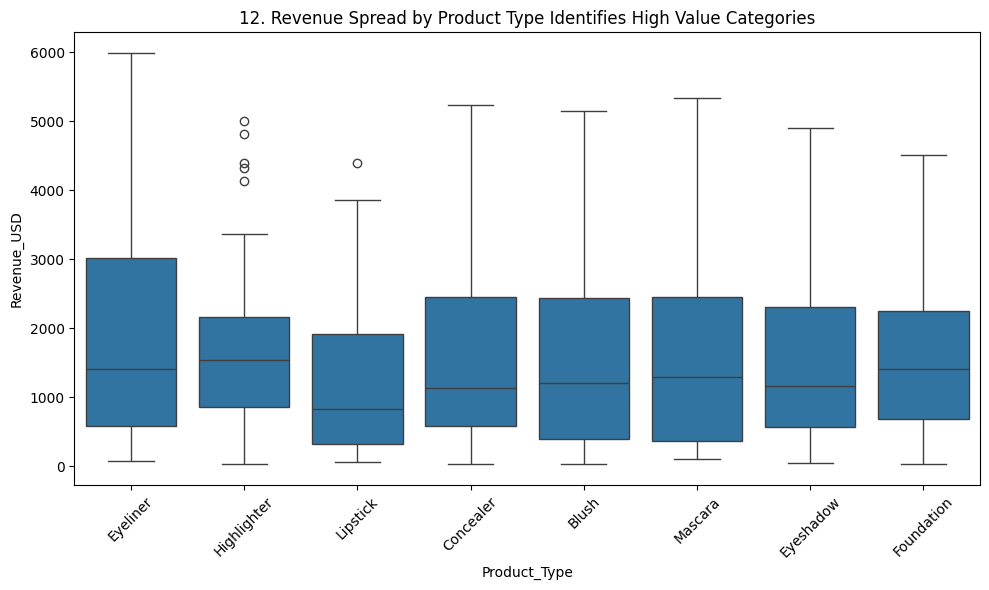

In [74]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Product_Type', y='Revenue_USD', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Revenue Spread by Product Type Identifies High Value Categories')
show_fig()
plot_no += 1

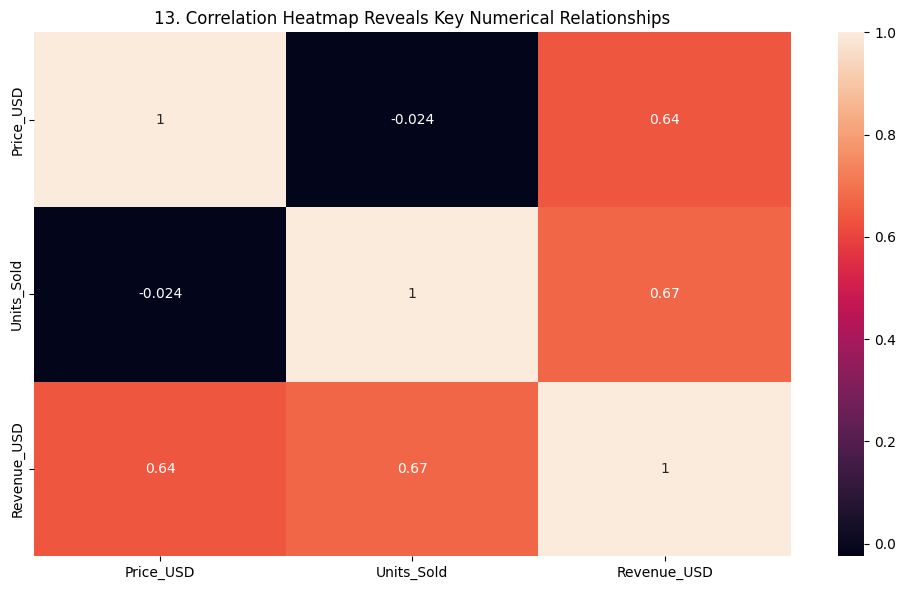

In [75]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[['Price_USD','Units_Sold','Revenue_USD']].corr(), annot=True)
plt.title(f'{plot_no}. Correlation Heatmap Reveals Key Numerical Relationships')
show_fig()
plot_no += 1

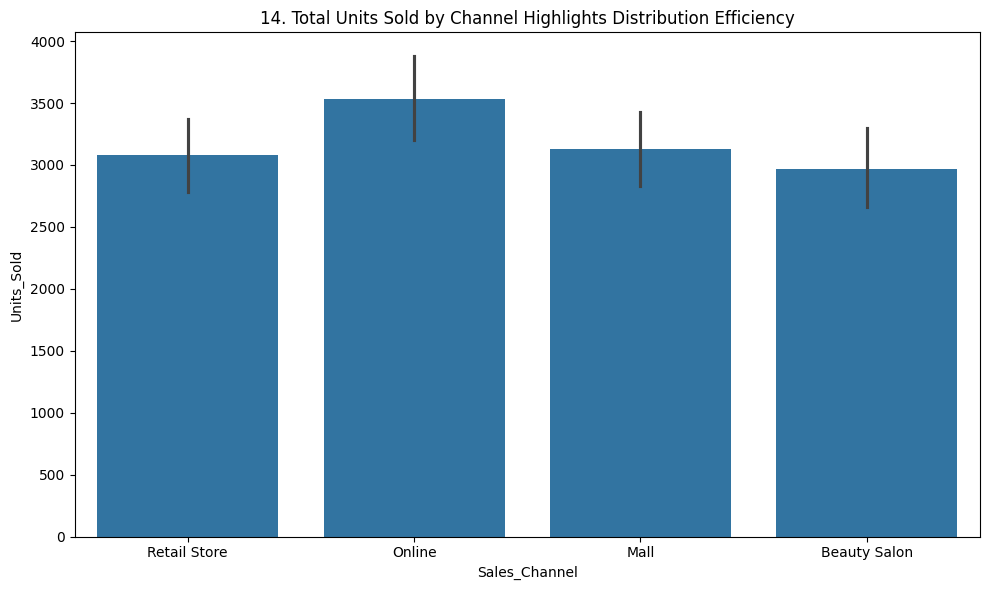

In [76]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Sales_Channel', y='Units_Sold', data=df, estimator=sum)
plt.title(f'{plot_no}. Total Units Sold by Channel Highlights Distribution Efficiency')
show_fig()
plot_no += 1

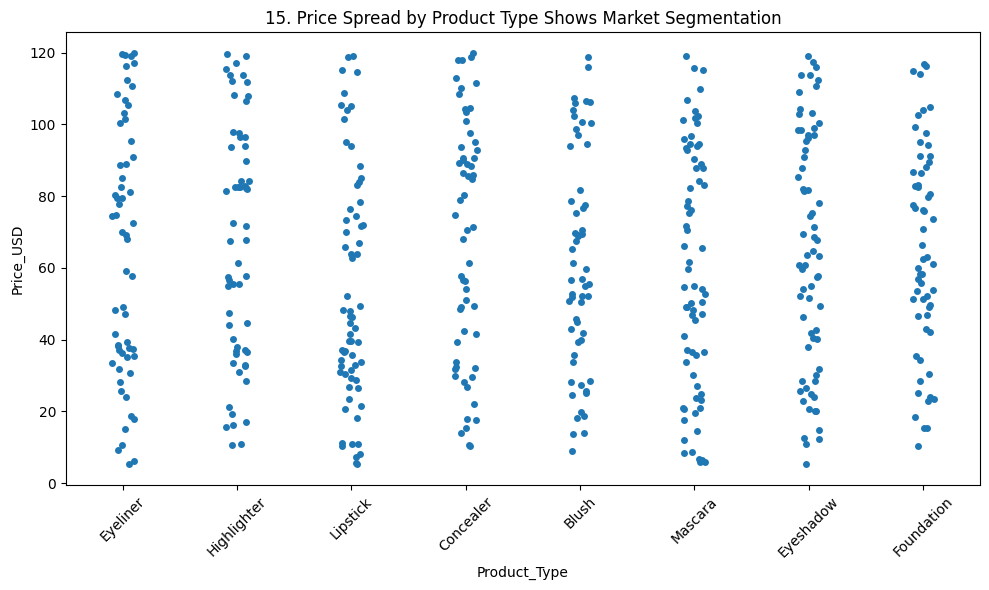

In [77]:
fig = plt.figure(figsize=(10,6))
sns.stripplot(x='Product_Type', y='Price_USD', data=df, jitter=True)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Price Spread by Product Type Shows Market Segmentation')
show_fig()
plot_no += 1

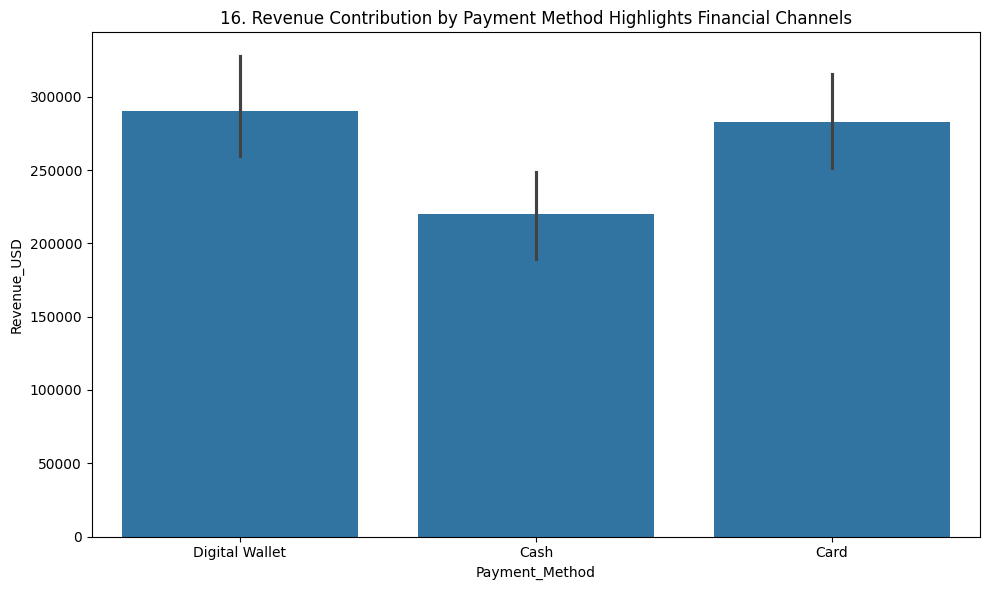

In [78]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Payment_Method', y='Revenue_USD', data=df, estimator=sum)
plt.title(f'{plot_no}. Revenue Contribution by Payment Method Highlights Financial Channels')
show_fig()
plot_no += 1

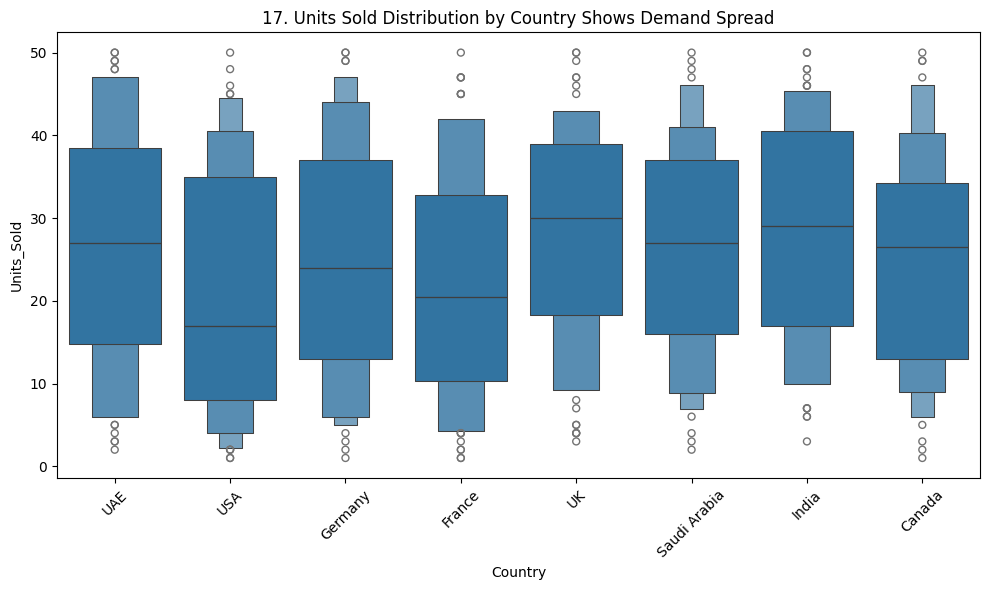

In [79]:
fig = plt.figure(figsize=(10,6))
sns.boxenplot(x='Country', y='Units_Sold', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Units Sold Distribution by Country Shows Demand Spread')
show_fig()
plot_no += 1

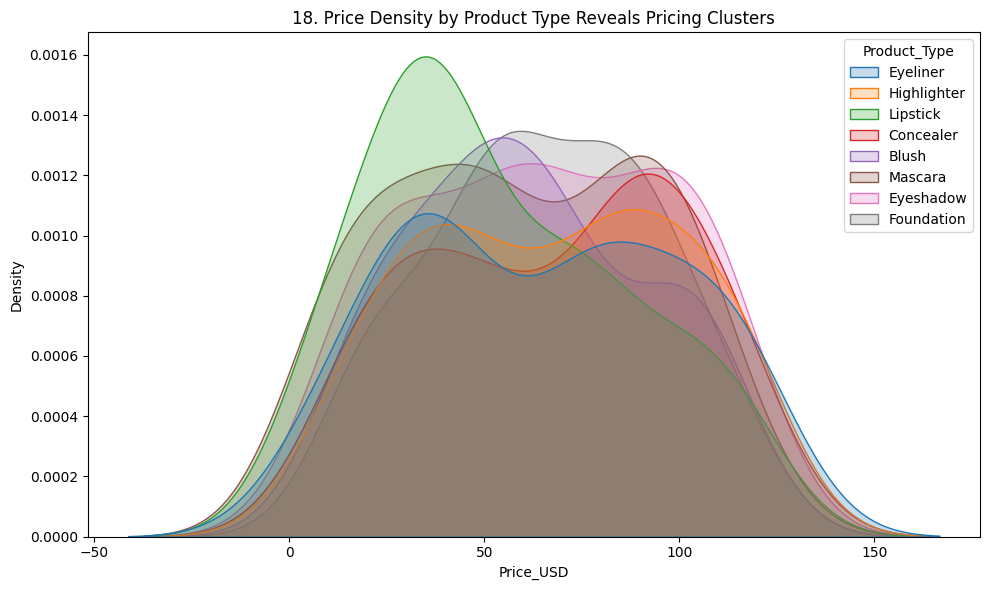

In [80]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Price_USD', hue='Product_Type', fill=True)
plt.title(f'{plot_no}. Price Density by Product Type Reveals Pricing Clusters')
show_fig()
plot_no += 1

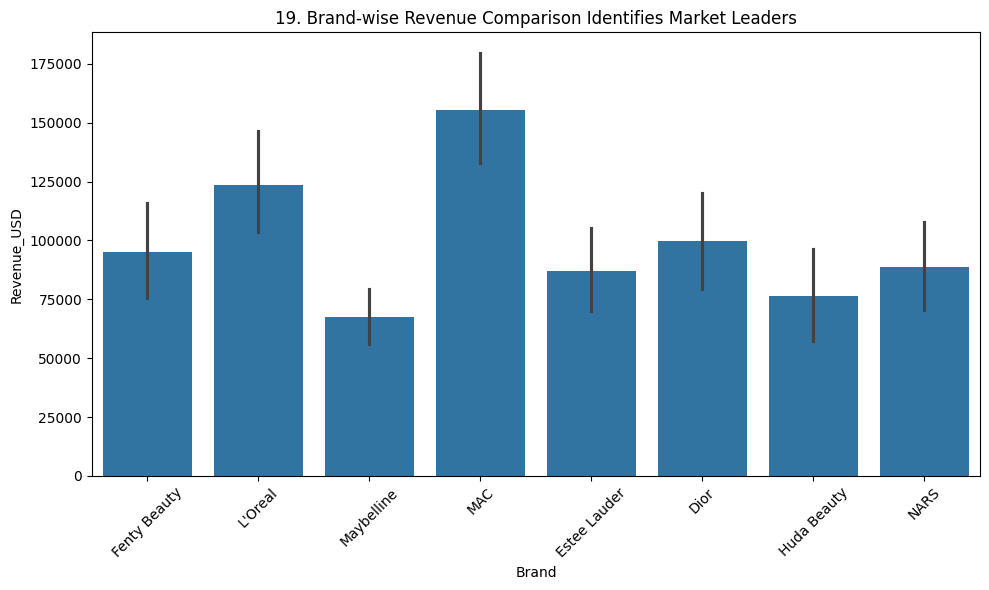

In [81]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='Brand', y='Revenue_USD', data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Brand-wise Revenue Comparison Identifies Market Leaders')
show_fig()
plot_no += 1

# Model Training

## create binary target based on median revenue

In [82]:
df['Target'] = (df['Revenue_USD'] > df['Revenue_USD'].median()).astype(int)

## select features and target

In [83]:
X = df[['Price_USD', 'Units_Sold']]
y = df['Target']

## split data into train and test

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [85]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train logistic regression model

In [86]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## make predictions

In [87]:
y_pred = model.predict(X_test)

## calculate accuracy

In [88]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc * 100)

Accuracy: 90.0


## plot confusion matrix

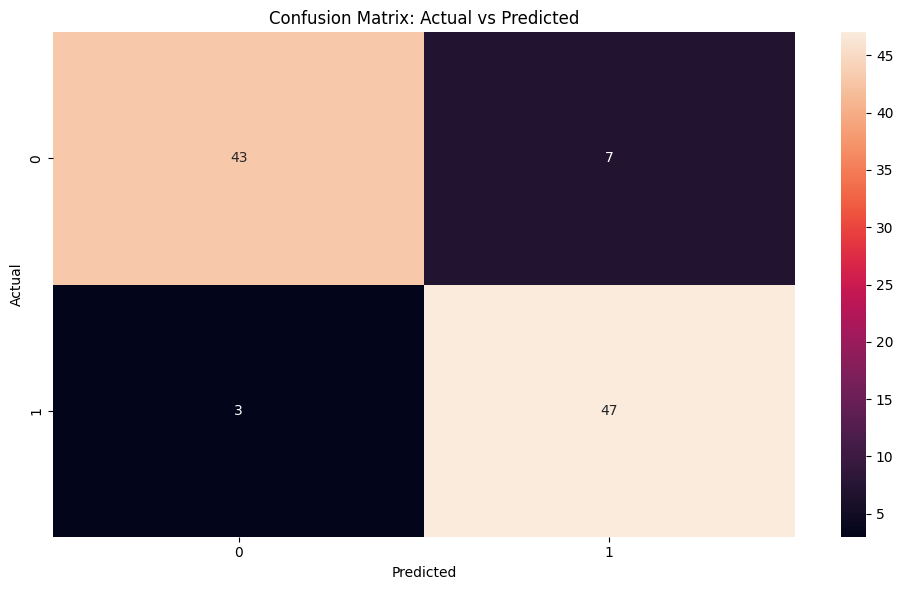

In [89]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()